# Exploration ProGEDO — quelles variables expliquent le choix du **vélo** ?

**Notebook d'analyse exploratoire.** Il ne remplace pas `prepare_progedo_logit.ipynb`, qui
reste la référence de production (jeu restreint aux traits *communs* avec le persona LLM).
Ici, l'objectif est **inverse** : ratisser le maximum de variables ProGEDO et laisser une
analyse de Shapley désigner celles qui portent réellement le signal vélo.

## Pourquoi
Le modèle actuel prédit mal le vélo (f1 = 0.23, précision = 0.14). Deux causes possibles :
1. la **part modale du vélo est de 3,9 %** — une partie du mauvais score est mécanique ;
2. les variables **déterminantes du vélo ont été filtrées** par le critère de communalité
   avec le persona, qui n'est pas un critère de pouvoir prédictif.

Ce notebook teste l'hypothèse 2.

## Trois choix de méthode

**a. Cible binaire `bike` vs reste, métrique PR-AUC.** À 3,9 % de positifs, l'accuracy
n'a aucun sens (98 % en prédisant toujours « non »). La PR-AUC se lit contre le taux de
base : 0.039 = aléatoire.

**b. Séparation Block A / Block B.** Le critère est : *l'information est-elle connue
avant la décision ?*
- **Block A — exogène** : socio-démo, équipement, géographie, saison, contexte du trajet.
  Le seul bloc dont les SHAP se lisent comme des **leviers**.
- **Block B — habitudes déclarées** (`P20` fréquence vélo, `P22` VP conducteur, `P24` TC…) :
  connu avant le trajet, donc exploitable en production, mais **quasi-tautologique** —
  `P20` n'est pas une cause du choix modal, c'est une autre mesure du même comportement.
  Isolé pour ne pas écraser le Block A, et parce qu'il mesure indirectement ce que la
  **LTM de l'agent LLM** est censée encoder.

*(Un « Block C » — durée `D9`, nb de trajets `D10` — a été écarté : dérivé du trajet
réalisé, donc inconnaissable au moment du choix.)*

**c. Séparation train/test par MÉNAGE.** Un individu produit plusieurs déplacements ; un
split par ligne ferait fuiter son identité entre train et test.

## Note sur `distance_km` (D12)
D12 est la *distance parcourue*, mesurée sur le réseau du mode utilisé — elle porte donc
une trace du choix. Facteurs de détour D12/D11 mesurés : marche 1.15, **vélo 1.40, voiture
1.51**, TC 1.50. Vélo et voiture sont quasi indiscernables : seule la marche est trahie.
Le biais est donc négligeable **pour une analyse centrée vélo** et D12 est conservé.
`D11` (vol d'oiseau, mode-neutre) est ajouté à côté sous le nom `crow_km`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np, geopandas as gpd
import matplotlib.pyplot as plt
import lightgbm as lgb, shap
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import average_precision_score, roc_auc_score

pd.set_option("display.max_columns", 80)

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT/"data"/"PROGEDO 2023").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
PROGEDO_DIR = PROJECT_ROOT/"data"/"PROGEDO 2023"/"lil-1750-Donnees_CSV"/"fichiers_standards"
SIG_ZF      = PROJECT_ROOT/"data"/"PROGEDO 2023"/"lil-1750-Documentation"/"SIG"/"EMC2_Toulouse_2023_ZF_26052023.shp"
OUT_DIR     = PROJECT_ROOT/"scripts"/"progedo_logit"
assert PROGEDO_DIR.exists() and SIG_ZF.exists()
print("OK :", PROGEDO_DIR)

OK : /Users/yvesb/Documents/Projects/llm-agents-gama/data/PROGEDO 2023/lil-1750-Donnees_CSV/fichiers_standards


## 1. Chargement

In [2]:
pers = pd.read_csv(PROGEDO_DIR/"Toulouse_2023_std_pers.csv", dtype=str)
men  = pd.read_csv(PROGEDO_DIR/"Toulouse_2023_std_men.csv",  dtype=str)
depl = pd.read_csv(PROGEDO_DIR/"Toulouse_2023_std_depl.csv", dtype=str)

# Codes ProGEDO : zéros de tête significatifs, cellules vides = non-enquêté.
# On normalise "" -> NaN : LightGBM gère nativement les manquants, donc on ne
# supprimera PAS les variables peu remplies (P18A n'est renseignée qu'à 48 %).
for df in (pers, men, depl):
    for c in df.columns:
        df[c] = df[c].str.strip().replace({"": np.nan})

print("pers:", pers.shape, "| men:", men.shape, "| depl:", depl.shape)

pers: (20890, 45) | men: (10783, 77) | depl: (54585, 29)


## 2. Bloc géographique — densité et gradient centre/périphérie

Le modèle actuel n'a **aucune** variable spatiale. Or le vélo est un mode de cœur d'agglo.
Le shapefile des zones fines fournit centroïde (`XL93`/`YL93`) et surface (`SURF_M2`) ;
la densité de ménages est estimée depuis l'enquête elle-même via les coefficients de
redressement `COE0`.

In [3]:
zf = gpd.read_file(SIG_ZF)[["ZF","XL93","YL93","SURF_M2"]]
zf["ZF"] = zf["ZF"].astype(str).str.strip()

w = men.assign(COE0=pd.to_numeric(men["COE0"], errors="coerce")).groupby("ZFM")["COE0"].sum()
zf["area_km2"]       = zf["SURF_M2"]/1e6
zf["density_hh_km2"] = zf["ZF"].map(w)/zf["area_km2"]

# Hypercentre = centroïde des zones fines du secteur 01 (Capitole ~ 574200/6279700 en L93)
core = zf[zf["ZF"].str.startswith("1011")]
CX, CY = core["XL93"].mean(), core["YL93"].mean()
zf["dist_center_km"] = np.hypot(zf["XL93"]-CX, zf["YL93"]-CY)/1000

GEO = zf.set_index("ZF")[["area_km2","density_hh_km2","dist_center_km"]]
print(f"Hypercentre L93 estimé : X={CX:.0f} Y={CY:.0f}")
GEO.describe().round(1)

Hypercentre L93 estimé : X=574406 Y=6278825


,area_km2,density_hh_km2,dist_center_km
count,785.0,704.0,785.0
mean,6.9,1421.0,19.7
std,8.5,2657.9,14.7
min,0.1,1.5,0.2
25%,0.8,27.4,6.5
50%,4.4,148.1,16.6
75%,9.8,1471.0,31.5
max,66.7,19572.4,61.1


## 3. Dictionnaires de recodage (étendus)

In [4]:
GENDER    = {"1":"Male","2":"Female"}
MAIN_OCC  = {"1":"Travail plein temps","2":"Travail temps partiel","3":"Alternance/stage",
             "4":"Étudiant","5":"Scolaire","6":"Chômeur","7":"Retraité","8":"Foyer","9":"Autre"}
SOCIOPRO  = {"01":"Agriculteur","02":"Artisan/Commerçant","03":"Cadre","04":"Interm.",
             "05":"Employé","06":"Ouvrier","07":"Élève/Étudiant","08":"Autre inactif",
             "09":"Autre inactif","00":None}
EDU       = {"00":"En cours","01":"Primaire","02":"Secondaire <bac","03":"Secondaire <bac",
             "04":"Bac","05":"Bac+2","06":"Bac+3 et +","07":"Apprentissage",
             "08":"Apprentissage sup","09":"Pas d'études","90":"Autre",
             "93":"Secondaire nd","97":"Apprentissage nd"}
LIEN      = {"1":"Réf.","2":"Conjoint","3":"Enfant","4":"Coloc/locataire",
             "5":"Autre parenté","6":"Autre sans parenté","7":"Autre"}
HABITAT   = {"1":"Individuel isolé","2":"Individuel accolé","3":"Petit collectif",
             "4":"Grand collectif","5":"Autre"}
OCCUP_LOG = {"1":"Propriétaire","2":"Locataire HLM","3":"Autre locataire","4":"Logé gratuit",
             "5":"Résidence univ.","6":"Autre","7":"Autre","8":"Locataire nd","9":None}
PARK_NUIT = {"1":"Garage/box réservé","2":"Rue","3":"Parc ciel ouvert",
             "4":"Parc couvert public","9":"Autre"}
VP_TRAV   = {"1":"Oui, jusqu'au lieu","2":"Oui, partiel","3":"Oui, non utilisée","4":"Non",
             "5":"Oui, partiel/pas","6":"Oui, tout/partie"}
PARK_VOIT = {"1":"Non","2":"Oui, place réservée","3":"Oui, offre importante",
             "4":"Oui, selon horaires","5":"Ne sait pas"}
PARK_VELO = {"1":"Oui, enceinte abrité","2":"Oui, enceinte non abrité","3":"Oui, proximité abrité",
             "4":"Oui, proximité non abrité","5":"Non","6":"Oui, enceinte nd",
             "7":"Oui, proximité nd","9":None}
FREQ      = {"1":"Plusieurs/semaine","2":"Plusieurs/mois","3":"Occasionnel","4":"Jamais"}
TELETRAV  = {"1":"Jamais","2":"1+ j/semaine","3":"Plusieurs j/mois","4":"Occasionnel"}
JOURS     = {"1":"Lundi","2":"Mardi","3":"Mercredi","4":"Jeudi","5":"Vendredi",
             "6":"Samedi","7":"Dimanche"}

# MODP -> cible. Identique à prepare_progedo_logit.ipynb pour rester comparable.
MODE_GROUP = {
    "01":"walk","93":"walk","94":"walk","96":"walk","97":"walk",
    "10":"bike","11":"bike","12":"bike","17":"bike","18":"bike",
    "21":"car","22":"car","61":"car","62":"car","81":"car","82":"car",
    "13":"car","14":"car","15":"car","16":"car","19":"car","20":"car",
    "31":"transit","32":"transit","33":"transit","34":"transit","37":"transit",
    "38":"transit","39":"transit","41":"transit","42":"transit","43":"transit",
    "51":"transit","52":"transit","53":"transit","54":"transit","71":"transit",
}

def purpose(c):
    if c in ("01","02"):                                              return "home"
    if c in ("11","12","13","14","81"):                               return "work"
    if c in ("21","22","23","24","25","26","27","28","29","96","97"): return "education"
    if c in ("30","31","32","33","34","35","82","98"):                return "shop"
    if c in ("51","52","53","54"):                                    return "leisure"
    return "other"

## 4. Table ménage étendue

Nouveautés vs le notebook actuel : `M23` (stationnement vélo au domicile), `M1`/`M2`
(type d'habitat et statut d'occupation → capacité de remisage), `M14` (deux-roues
motorisés, mode concurrent), `M12A` (stationnement nocturne de la voiture), et surtout
`M21` conservé **en effectif** au lieu d'être écrasé en booléen `has_bike`.

In [5]:
men_feat = pd.DataFrame({
    "ZF": men["ZFM"], "ECH": men["ECH"],
    "number_of_cars":    pd.to_numeric(men["M6"],  errors="coerce"),
    "n_bikes":           pd.to_numeric(men["M21"], errors="coerce"),
    "n_motorbikes":      pd.to_numeric(men["M14"], errors="coerce"),
    "bike_parking_home": men["M23"].map({"1": True, "2": False}),
    "housing_type":      men["M1"].map(HABITAT),
    "housing_tenure":    men["M2"].map(OCCUP_LOG),
    "car_night_parking": men["M12A"].map(PARK_NUIT),
}).drop_duplicates(["ZF","ECH"])
men_feat["has_bike"] = men_feat["n_bikes"].fillna(0) > 0
print(men_feat.shape); men_feat.head(3)

(10783, 10)


,ZF,ECH,number_of_cars,n_bikes,n_motorbikes,bike_parking_home,housing_type,housing_tenure,car_night_parking,has_bike
0,101101000,10001,0,0,0,False,Petit collectif,Autre locataire,NaN,False
1,101101000,10018,0,0,0,True,Petit collectif,Autre locataire,NaN,False
2,101101000,10019,1,0,0,True,Grand collectif,Autre locataire,Garage/box réservé,False


## 5. Table personne étendue

Nouveautés : `P8` (niveau d'études — **meilleur proxy de revenu disponible**, ProGEDO ne
collecte pas le revenu), `P16`/`P18`/`P18A` (disponibilité VP et stationnement voiture/vélo
sur le lieu de travail : le vélo se choisit aussi quand la voiture est pénible), `P14`
(travail à domicile), `DP15` (distance domicile-travail), `P3` (lien au chef de ménage),
`MOIS`/`JOUR` (**saison et jour de semaine, totalement absents du modèle actuel**).

Le **Block B** est construit ici mais gardé à part.

In [6]:
hh_size = pers.groupby(["ZFP","ECH"]).size().rename("household_size").reset_index()
lic_hh  = (pers.assign(_l=(pers["P7"]=="1"))
               .groupby(["ZFP","ECH"])["_l"].sum().rename("n_licensed").reset_index())
kid_hh  = (pers.assign(_k=pd.to_numeric(pers["P4"], errors="coerce") < 15)
               .groupby(["ZFP","ECH"])["_k"].sum().rename("n_children").reset_index())

pers_feat = pd.DataFrame({
    "ZF": pers["ZFP"], "ECH": pers["ECH"], "PER": pers["PER"], "PENQ": pers["PENQ"],
    # --- socio-démographie ---
    "age":                     pd.to_numeric(pers["P4"], errors="coerce"),
    "gender":                  pers["P2"].map(GENDER),
    "hh_relationship":         pers["P3"].map(LIEN),
    "education_level":         pers["P8"].map(EDU),
    "socioprofessional_class": pers["PCSC"].map(SOCIOPRO),
    "main_occupation":         pers["P9"].map(MAIN_OCC),
    "secondary_occupation":    pers["P10"].map({"0":"Non concerné","1":"Travail","2":"Études"}),
    "employed":                pers["P9"].isin({"1","2"}),
    "studies":                 pers["P9"].isin({"3","4","5"}),
    # --- équipement individuel ---
    "has_driving_license":     pers["P7"] == "1",
    "has_pt_subscription":     pers["P12"].map({"4": False, "6": True}),
    # --- contexte travail / études ---
    "works_from_home":         pers["P14"].map({"1": True, "2": False}),
    "commute_crow_km":         pd.to_numeric(pers["DP15"], errors="coerce")/1000,
    "car_avail_commute":       pers["P16"].map(VP_TRAV),
    "car_parking_work":        pers["P18"].map(PARK_VOIT),
    "bike_parking_work":       pers["P18A"].map(PARK_VELO),
    # --- temporalité ---
    "survey_month":            pers["MOIS"],
    "survey_weekday":          pers["JOUR"].map(JOURS),
    "weight_person":           pd.to_numeric(pers["COEP"], errors="coerce"),
    # --- BLOCK B : habitudes déclarées (quasi-tautologiques) ---
    "freq_bike":               pers["P20"].map(FREQ),
    "freq_motorbike":          pers["P21"].map(FREQ),
    "freq_car_driver":         pers["P22"].map(FREQ),
    "freq_transit":            pers["P24"].map(FREQ),
    "telework":                pers["P13B"].map(TELETRAV),
})

for agg in (hh_size, lic_hh, kid_hh):
    pers_feat = pers_feat.merge(agg, left_on=["ZF","ECH"], right_on=["ZFP","ECH"],
                                how="left").drop(columns="ZFP")
pers_feat = pers_feat.merge(men_feat, on=["ZF","ECH"], how="left")

def car_availability(row):
    cars = row["number_of_cars"]
    if pd.isna(cars):            return np.nan
    if cars == 0:                return "none"
    lic = row["n_licensed"]
    if pd.isna(lic) or lic == 0: return "all"
    return "all" if cars >= lic else "some"

pers_feat["car_availability"]  = pers_feat.apply(car_availability, axis=1)
pers_feat["cars_per_licensed"] = pers_feat["number_of_cars"]/pers_feat["n_licensed"].replace(0, np.nan)
pers_feat["bikes_per_person"]  = pers_feat["n_bikes"]/pers_feat["household_size"]
print(pers_feat.shape); pers_feat.head(3)

(20890, 42)


,ZF,ECH,PER,PENQ,age,gender,hh_relationship,education_level,socioprofessional_class,main_occupation,secondary_occupation,employed,studies,has_driving_license,has_pt_subscription,works_from_home,commute_crow_km,car_avail_commute,car_parking_work,bike_parking_work,survey_month,survey_weekday,weight_person,freq_bike,freq_motorbike,freq_car_driver,freq_transit,telework,household_size,n_licensed,n_children,number_of_cars,n_bikes,n_motorbikes,bike_parking_home,housing_type,housing_tenure,car_night_parking,has_bike,car_availability,cars_per_licensed,bikes_per_person
0,101101000,10001,1,1,18,Male,Réf.,En cours,Élève/Étudiant,Étudiant,Non concerné,False,True,False,True,False,1.924,Non,Non,"Oui, enceinte non abrité",10,Mercredi,84.24878,Jamais,Jamais,Jamais,Plusieurs/semaine,NaN,1,0,0,0,0,0,False,Petit collectif,Autre locataire,NaN,False,none,NaN,0.0
1,101101000,10018,1,1,23,Female,Coloc/locataire,En cours,Élève/Étudiant,Étudiant,Non concerné,False,True,False,True,False,3.743,Non,"Oui, offre importante","Oui, enceinte abrité",10,Mardi,82.34892,Jamais,Jamais,Jamais,Plusieurs/semaine,NaN,2,0,0,0,0,0,True,Petit collectif,Autre locataire,NaN,False,none,NaN,0.0
2,101101000,10018,2,1,22,Male,Réf.,En cours,Élève/Étudiant,Étudiant,Non concerné,False,True,False,True,False,3.743,Non,"Oui, offre importante","Oui, enceinte abrité",10,Mardi,86.11934,Jamais,Jamais,Jamais,Plusieurs/semaine,NaN,2,0,0,0,0,0,True,Petit collectif,Autre locataire,NaN,False,none,NaN,0.0


## 6. Table déplacements étendue + jointure géographique

Nouveautés : `D2A` (motif à l'**origine** — le modèle actuel n'utilise que la destination),
`D11` (vol d'oiseau), `D6` (arrêts sur la tournée), `TYPD` (interne/échange/externe),
et la géographie jointe sur les zones fines d'origine (`D3`) et de destination (`D7`).

In [7]:
dep = pd.DataFrame({
    "ZF": depl["ZFD"], "ECH": depl["ECH"], "PER": depl["PER"], "NDEP": depl["NDEP"],
    "mode":            depl["MODP"].map(MODE_GROUP),
    "purpose":         depl["D5A"].map(purpose),
    "purpose_origin":  depl["D2A"].map(purpose),
    "distance_km":     pd.to_numeric(depl["D12"], errors="coerce")/1000,  # cf. note d'entête
    "crow_km":         pd.to_numeric(depl["D11"], errors="coerce")/1000,  # mode-neutre
    "departure_hour":  (pd.to_numeric(depl["D4"], errors="coerce")//100) % 24,
    "n_stops_tour":    pd.to_numeric(depl["D6"], errors="coerce"),
    "trip_scope":      depl["TYPD"].map({"1":"Interne","2":"Échange","3":"Externe","9":None}),
    "ZF_orig": depl["D3"], "ZF_dest": depl["D7"],
})

for side in ("orig", "dest"):
    j = GEO.reindex(dep[f"ZF_{side}"]).reset_index(drop=True)
    dep[f"density_{side}"]           = j["density_hh_km2"].values
    dep[f"dist_center_{side}_km"]    = j["dist_center_km"].values

df = dep.merge(pers_feat, on=["ZF","ECH","PER"], how="left")
df = df[df["mode"].notna() & (df["PENQ"] == "1")]
df = df.dropna(subset=["age", "distance_km"])          # seules exclusions : cible/distance
df["is_bike"] = (df["mode"] == "bike").astype(int)
df["hh_id"]   = df["ZF"].astype(str) + "_" + df["ECH"].astype(str)

print(f"N = {len(df)} déplacements | {df['hh_id'].nunique()} ménages "
      f"| part vélo = {df['is_bike'].mean()*100:.2f}%")
print(f"géographie renseignée : {df['density_orig'].notna().mean()*100:.0f}% "
      f"(les zones hors périmètre d'enquête n'ont pas de densité)")

N = 54559 déplacements | 9659 ménages | part vélo = 3.89%
géographie renseignée : 72% (les zones hors périmètre d'enquête n'ont pas de densité)


### Part modale du vélo par variable candidate

In [8]:
for v in ["bike_parking_home","bike_parking_work","education_level",
          "car_parking_work","housing_type","survey_month","freq_bike"]:
    s = df.groupby(v, dropna=False)["is_bike"].agg(part_velo_pct="mean", n="size")
    s["part_velo_pct"] = (s["part_velo_pct"]*100).round(2)
    print(f"\n--- {v} ---\n{s.sort_values('part_velo_pct', ascending=False).to_string()}")


--- bike_parking_home ---
                   part_velo_pct      n
bike_parking_home                      
True                        4.01  43360
False                       3.45  11199

--- bike_parking_work ---
                           part_velo_pct      n
bike_parking_work                              
Oui, proximité non abrité           5.54   2023
Oui, enceinte abrité                5.37  14570
Oui, enceinte non abrité            4.66   5412
NaN                                 3.06  28614
Non                                 2.92   2914
Oui, proximité abrité               1.56   1026

--- education_level ---
                   part_velo_pct      n
education_level                        
Apprentissage sup          10.00     80
Bac+3 et +                  5.90  16956
Apprentissage               4.95    101
En cours                    4.10  11959
Bac+2                       2.92   6955
Bac                         2.58   6978
Secondaire <bac             2.34   9971
Pas d'études     

## 7. Définition des blocs et protocole d'évaluation

Le split est fait **par ménage** (`GroupShuffleSplit` sur `hh_id`) : les déplacements d'une
même personne ne peuvent pas se retrouver des deux côtés.

In [9]:
# Les 15 variables du modèle actuel, à l'identique — sert de point de comparaison
BASELINE = ["age","gender","household_size","has_driving_license","has_pt_subscription",
            "number_of_cars","car_availability","has_bike","socioprofessional_class",
            "main_occupation","employed","studies","purpose","distance_km","departure_hour"]

BLOCK_A = BASELINE + [
    # socio-démographie étendue
    "education_level","hh_relationship","secondary_occupation","n_children",
    # équipement du ménage
    "n_bikes","bikes_per_person","n_motorbikes","bike_parking_home","cars_per_licensed",
    "housing_type","housing_tenure","car_night_parking",
    # contexte travail / études
    "works_from_home","commute_crow_km","car_avail_commute","car_parking_work","bike_parking_work",
    # contexte du déplacement
    "purpose_origin","crow_km","n_stops_tour","trip_scope","survey_month","survey_weekday",
    # géographie
    "density_orig","density_dest","dist_center_orig_km","dist_center_dest_km",
]
BLOCK_B = ["freq_bike","freq_motorbike","freq_car_driver","freq_transit","telework"]
NEW_IN_A = set(BLOCK_A) - set(BASELINE)

def prep(cols):
    X = df[cols].copy()
    for c in X.columns:
        if not pd.api.types.is_numeric_dtype(X[c]) or pd.api.types.is_bool_dtype(X[c]):
            X[c] = X[c].astype("category")     # LightGBM gère catégories et NaN nativement
    return X

tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=0)
              .split(df, groups=df["hh_id"]))
y = df["is_bike"].values
print(f"train = {len(tr)} | test = {len(te)} | part vélo test = {y[te].mean()*100:.2f}%")

train = 40641 | test = 13918 | part vélo test = 3.93%


In [10]:
def run(name, cols):
    X = prep(cols)
    m = lgb.LGBMClassifier(n_estimators=600, learning_rate=0.05, num_leaves=31,
                           min_child_samples=40, subsample=0.8, colsample_bytree=0.8,
                           is_unbalance=True, random_state=0, verbose=-1)
    m.fit(X.iloc[tr], y[tr])
    p  = m.predict_proba(X.iloc[te])[:, 1]
    ap = average_precision_score(y[te], p)
    print(f"{name:36s} PR-AUC={ap:.4f}  ROC-AUC={roc_auc_score(y[te], p):.4f}  ({len(cols)} vars)")
    return m, X, ap

print("=== Prédiction du VÉLO (binaire) — PR-AUC, taux de base = "
      f"{y[te].mean():.4f} ===\n")
m0, X0, ap0 = run("0. Baseline (15 vars actuelles)", BASELINE)
mA, XA, apA = run("A. Block A (exogène étendu)",     BLOCK_A)
mB, XB, apB = run("A+B (avec habitudes déclarées)",  BLOCK_A + BLOCK_B)
print(f"\ngain A vs baseline : x{apA/ap0:.2f}   |   gain A+B vs A : x{apB/apA:.2f}")

=== Prédiction du VÉLO (binaire) — PR-AUC, taux de base = 0.0393 ===



0. Baseline (15 vars actuelles)      PR-AUC=0.2304  ROC-AUC=0.8492  (15 vars)


A. Block A (exogène étendu)          PR-AUC=0.4103  ROC-AUC=0.8984  (42 vars)


A+B (avec habitudes déclarées)       PR-AUC=0.6007  ROC-AUC=0.9645  (47 vars)

gain A vs baseline : x1.78   |   gain A+B vs A : x1.46


## 8. Analyse de Shapley — Block A

TreeSHAP sur le modèle Block A. On lit ici les variables **exogènes**, donc interprétables
comme des leviers.

In [11]:
expl  = shap.TreeExplainer(mA)
samp  = XA.iloc[te].sample(min(8000, len(te)), random_state=0)
sv    = expl.shap_values(samp)
if isinstance(sv, list): sv = sv[1]
if sv.ndim == 3:         sv = sv[:, :, 1]

imp_A = pd.Series(np.abs(sv).mean(0), index=samp.columns).sort_values(ascending=False)
tbl = imp_A.rename("mean_abs_shap").to_frame()
tbl["nouvelle"] = ["★" if k in NEW_IN_A else "" for k in tbl.index]
print("★ = variable absente du modèle actuel\n")
print(tbl.head(25).round(5).to_string())

★ = variable absente du modèle actuel

                         mean_abs_shap nouvelle
distance_km                    1.62526         
has_bike                       0.73931         
car_avail_commute              0.69372        ★
bikes_per_person               0.68840        ★
crow_km                        0.58486        ★
age                            0.48874         
purpose_origin                 0.37992        ★
gender                         0.37521         
purpose                        0.32353         
n_bikes                        0.32205        ★
commute_crow_km                0.28105        ★
number_of_cars                 0.26133         
survey_month                   0.24110        ★
dist_center_orig_km            0.23187        ★
dist_center_dest_km            0.19409        ★
education_level                0.19099        ★
has_pt_subscription            0.18343         
density_orig                   0.17571        ★
main_occupation                0.15651         
d

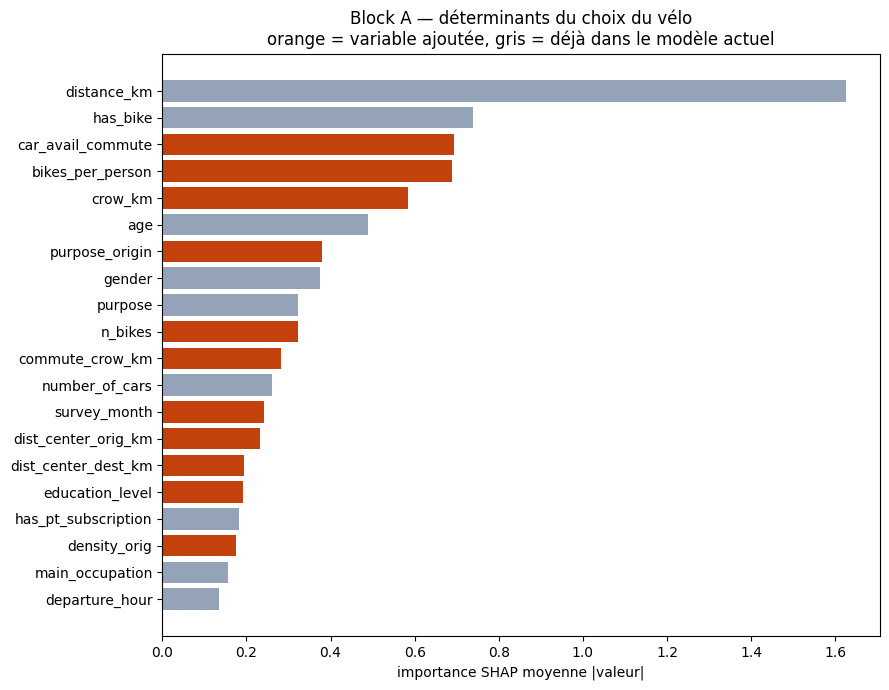

In [12]:
top = imp_A.head(20).iloc[::-1]
colors = ["#c2410c" if k in NEW_IN_A else "#94a3b8" for k in top.index]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top.index, top.values, color=colors)
ax.set_xlabel("importance SHAP moyenne |valeur|")
ax.set_title("Block A — déterminants du choix du vélo\n"
             "orange = variable ajoutée, gris = déjà dans le modèle actuel")
plt.tight_layout(); plt.show()

### Direction de l'effet (beeswarm)
Les catégorielles sont encodées en codes ordonnés — lire la magnitude, pas le signe de la couleur.

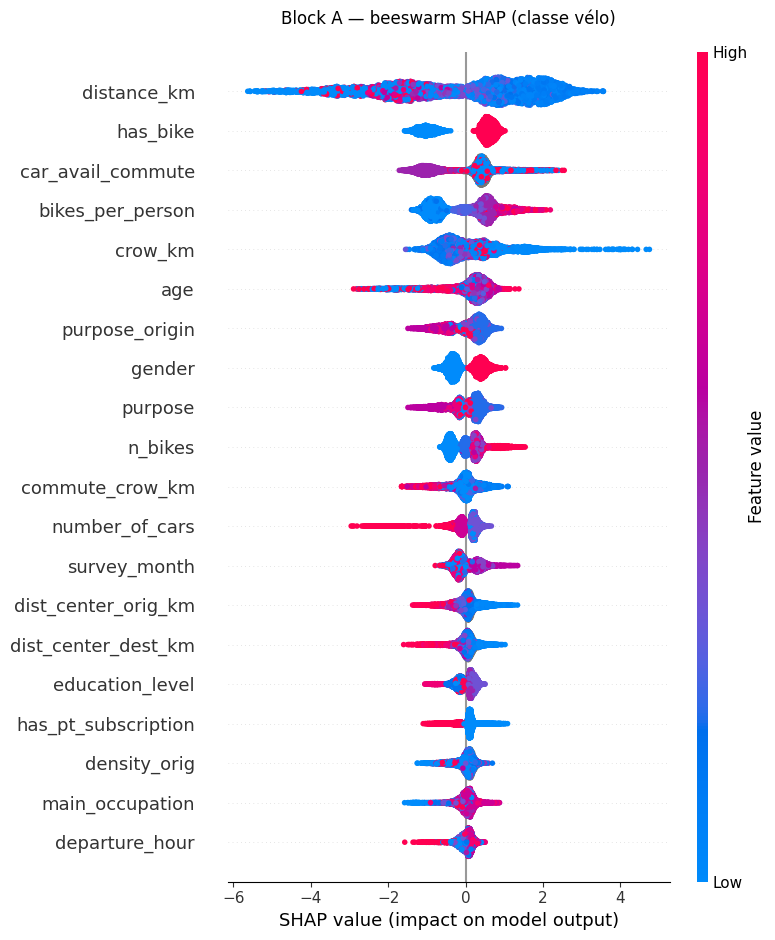

In [13]:
samp_num = samp.copy()
for c in samp_num.columns:
    if isinstance(samp_num[c].dtype, pd.CategoricalDtype):
        samp_num[c] = samp_num[c].cat.codes.replace(-1, np.nan)
shap.summary_plot(sv, samp_num, max_display=20, show=False)
plt.title("Block A — beeswarm SHAP (classe vélo)", pad=20)
plt.tight_layout(); plt.show()

### Effet détaillé des principales catégorielles

In [14]:
sv_df = pd.DataFrame(sv, index=samp.index, columns=samp.columns)
for v in ["car_avail_commute","education_level","survey_month","bike_parking_work","car_parking_work"]:
    g = pd.DataFrame({"shap": sv_df[v], "val": samp[v].astype(object)})
    r = g.groupby("val", dropna=False)["shap"].agg(shap_moyen="mean", n="size")
    r = r[r["n"] >= 30].sort_values("shap_moyen", ascending=False).round(4)
    print(f"\n--- {v} (SHAP > 0 = pousse vers le vélo) ---\n{r.to_string()}")


--- car_avail_commute (SHAP > 0 = pousse vers le vélo) ---
                    shap_moyen     n
val                                 
Oui, non utilisée       1.0541   461
Non                     0.9414   885
NaN                     0.3906  3895
Oui, partiel           -0.3539   146
Oui, jusqu'au lieu     -1.0151  2613

--- education_level (SHAP > 0 = pousse vers le vélo) ---
                 shap_moyen     n
val                              
Bac+3 et +           0.2194  2537
En cours             0.1250  1748
Secondaire <bac     -0.0977  1466
Bac                 -0.1672  1013
Bac+2               -0.2621  1001
Pas d'études        -0.5785    31
Primaire            -0.7854   180

--- survey_month (SHAP > 0 = pousse vers le vélo) ---
     shap_moyen     n
val                  
09       0.3601   959
10       0.3346  1756
02      -0.0611   392
11      -0.1621  2002
01      -0.1959  1656
12      -0.2020  1235

--- bike_parking_work (SHAP > 0 = pousse vers le vélo) ---
                          

### Effet des variables continues clés

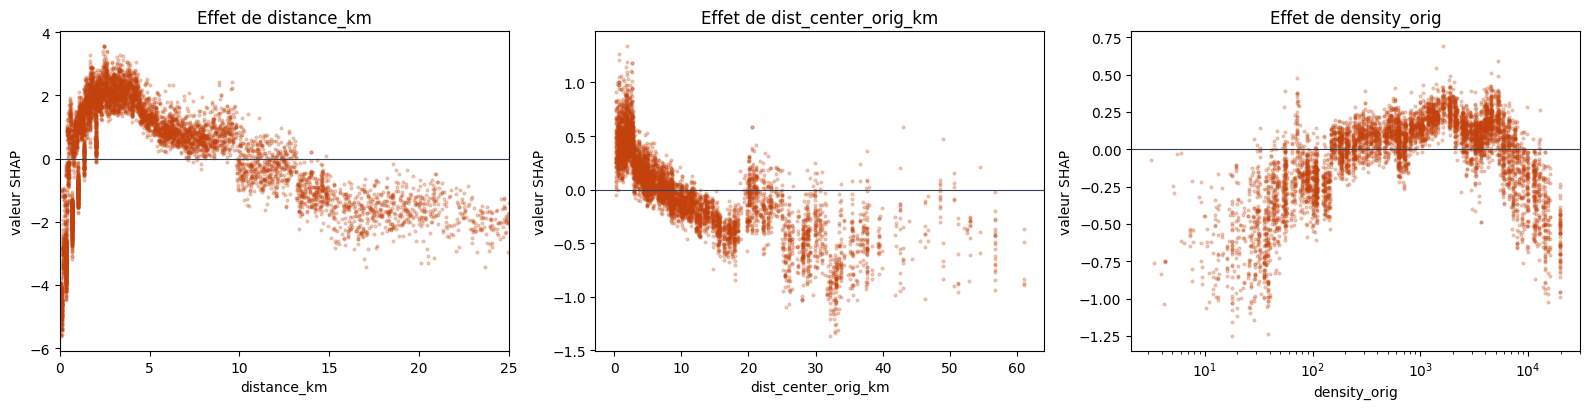

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, v in zip(axes, ["distance_km", "dist_center_orig_km", "density_orig"]):
    ax.scatter(samp[v], sv_df[v], s=4, alpha=0.25, color="#c2410c")
    ax.axhline(0, color="#334155", lw=0.8)
    ax.set_xlabel(v); ax.set_ylabel("valeur SHAP")
    ax.set_title(f"Effet de {v}")
    if v == "distance_km": ax.set_xlim(0, 25)
    if v == "density_orig": ax.set_xscale("log")
plt.tight_layout(); plt.show()

## 9. Block B — combien d'explication tient dans l'habitude déclarée ?

`freq_bike` (`P20`) atteignait 25,2 % de part vélo chez « plusieurs jours/semaine » contre
0,03 % chez « jamais ». On vérifie ici à quel point elle écrase le Block A.

In [16]:
e2  = shap.TreeExplainer(mB)
s2  = XB.iloc[te].sample(min(8000, len(te)), random_state=0)
v2  = e2.shap_values(s2)
if isinstance(v2, list): v2 = v2[1]
if v2.ndim == 3:         v2 = v2[:, :, 1]

imp_B = pd.Series(np.abs(v2).mean(0), index=s2.columns).sort_values(ascending=False)
t2 = imp_B.rename("mean_abs_shap").to_frame()
t2["block"] = ["▲ B (habitude)" if k in set(BLOCK_B) else "A" for k in t2.index]
print(t2.head(15).round(5).to_string())

part = imp_B[imp_B.index.isin(BLOCK_B)].sum()/imp_B.sum()
print(f"\nLe Block B capte {part*100:.1f}% de l'importance SHAP totale "
      f"avec seulement {len(BLOCK_B)} variables sur {len(BLOCK_A)+len(BLOCK_B)}.")

                     mean_abs_shap           block
freq_bike                  2.02859  ▲ B (habitude)
distance_km                1.37243               A
crow_km                    0.62331               A
purpose_origin             0.37677               A
car_avail_commute          0.36350               A
has_bike                   0.32512               A
bikes_per_person           0.31056               A
age                        0.30900               A
purpose                    0.26549               A
freq_car_driver            0.26426  ▲ B (habitude)
freq_transit               0.25662  ▲ B (habitude)
survey_month               0.24627               A
commute_crow_km            0.21404               A
dist_center_dest_km        0.17085               A
departure_hour             0.15749               A

Le Block B capte 28.6% de l'importance SHAP totale avec seulement 5 variables sur 47.


## 10. Export

In [17]:
export_cols = (["hh_id","ZF","ECH","PER","NDEP","mode","is_bike","weight_person"]
               + BLOCK_A + BLOCK_B)
out = df[[c for c in dict.fromkeys(export_cols)]].reset_index(drop=True)
path = OUT_DIR/"progedo_bike_exploration.csv"
out.to_csv(path, index=False)
imp_A.rename("mean_abs_shap").to_csv(OUT_DIR/"progedo_bike_shap_blockA.csv")
print("Écrits :")
print(" -", path, out.shape)
print(" -", OUT_DIR/"progedo_bike_shap_blockA.csv")

Écrits :
 - /Users/yvesb/Documents/Projects/llm-agents-gama/scripts/progedo_logit/progedo_bike_exploration.csv (54559, 55)
 - /Users/yvesb/Documents/Projects/llm-agents-gama/scripts/progedo_logit/progedo_bike_shap_blockA.csv


## 11. Lecture des résultats

### Le diagnostic initial est confirmé
La PR-AUC vélo passe de **0.230** (15 variables actuelles) à **0.410** avec le Block A —
**×1.78 à modèle et protocole identiques**. Le problème vélo venait bien de variables
manquantes, pas seulement du déséquilibre de classe. **15 des 25 premières variables SHAP
sont des variables absentes du modèle actuel.**

### Ce qui compte vraiment
1. **`car_avail_commute` (P16, rang 3)** — la disponibilité d'une voiture pour le trajet
   domicile-travail, et de loin la variable ajoutée la plus forte. Le vélo se décide
   largement *contre* la voiture. L'effet est net et monotone :
   « Oui, jusqu'au lieu » SHAP −1.02, « Oui, partiel » −0.35, « Non » +0.94,
   « Oui, mais non utilisée » +1.05. C'est l'effet de **concurrence**, entièrement absent
   du modèle actuel.

   ⚠️ **Attention à `car_parking_work` (P18), qui s'inverse.** En taux brut, l'absence de
   stationnement voiture au travail est associée à plus de vélo (5,79 % contre 3,86 % avec
   une place réservée) — l'histoire attendue. Mais *à conditions égales*, le SHAP donne le
   contraire (place réservée +0.11, pas de stationnement −0.22). L'effet marginal était
   porté par des variables corrélées (localisation du lieu de travail, `car_avail_commute`)
   et non par le stationnement lui-même. C'est une inversion de type Simpson : ne pas lire
   P18 comme un levier, et se méfier des taux bruts en général dans ce tableau.
2. **`bikes_per_person` (rang 4) et `n_bikes` (rang 10)** — l'écrasement de `M21` en booléen
   `has_bike` détruisait de l'information. Un ménage avec un vélo par personne n'est pas un
   ménage avec un vélo pour cinq.
3. **La géographie (rangs 14, 15, 18, 22)** — `dist_center_orig_km`, `dist_center_dest_km`,
   `density_orig`, `density_dest`. Quatre variables dans le top 25 pour un axe totalement
   absent du modèle actuel.
4. **`survey_month` (rang 13)** — la saison. 5,05 % de vélo en septembre contre 3,05 % en
   février.
5. **`education_level` (rang 16)** — de 0,17 % (primaire) à 5,90 % (bac+3 et plus). Le
   meilleur substitut de revenu disponible dans ProGEDO, partiellement confondu avec l'âge.

### Ce qui ne compte pas — une prédiction démentie
**`bike_parking_home` (M23) finit 38ᵉ sur 42.** Le stationnement vélo au domicile est le
déterminant canonique du vélo dans la littérature, mais il ne discrimine pas ici : **79 %
des ménages toulousains en disposent**, la variable est donc presque constante. Même chose
pour `works_from_home` (40ᵉ) et `n_stops_tour` (42ᵉ, importance nulle). À écarter.

`bike_parking_work` (P18A) est plus intéressant mais reste 28ᵉ, et fragile : seule la
modalité « abrité dans l'enceinte » ressort positivement (SHAP +0.12, n=2193), tandis que
« à proximité et abrité » sort le plus négatif de tous (−0.29) sur seulement 141
observations — donc du bruit. La variable n'est renseignée que pour 48 % des déplacements.
Signal réel mais à manier avec prudence.

### Ce que le Block B raconte sur l'architecture de l'agent
Ajouter les habitudes déclarées fait passer la PR-AUC de 0.410 à **0.601** (×1.46), et
`freq_bike` devient à elle seule la première variable du modèle — devant la distance
(2.03 contre 1.37). À elles seules, les **5 variables du Block B captent 28,6 % de
l'importance SHAP totale** d'un modèle qui en compte 47.

C'est un résultat sur **ton dispositif mémoire**, pas seulement sur ProGEDO. Une fraction
substantielle du signal vélo n'est pas structurelle (socio-démo, géographie, équipement)
mais **habituelle** : elle réside dans l'historique de la personne. C'est exactement ce que
la LTM de l'agent LLM est censée porter. Deux conséquences :
- un agent sans mémoire des trajets passés a un **plafond de performance** sur le vélo,
  quelle que soit la richesse de son persona ;
- une trait de persona « fréquence d'usage du vélo » serait le levier de calibration le plus
  rentable, à une variable près.

### Suites possibles
- **Enrichir le persona** avec les variables du top 10 exogène qui ont un équivalent
  simulable : disponibilité VP pour le motif, nombre de vélos par personne, densité de la
  zone de résidence.
- **Fix 2 (choice set OTP)** — en attente de ta décision. Router chaque paire OD ProGEDO
  pour les 4 modes reproduirait exactement la structure du prompt de l'agent
  (`llm_agent.py:333` fournit une option par mode) et permettrait un logit conditionnel.